# Bayesian AVO Inversion

=============================================================================

Part 1: InverseProblem framework demo — simple curve-fitting task showing
how `InverseProblem` bridges deterministic (`create_inverter()`)
and Bayesian (`as_posterior()`) solvers.

Part 2: Full Bayesian AVO inversion with all four samplers (SVGD, HMC,
NUTS, LDS) using the Explicit parameterization strategy.

Forward model (Part 2):
porosity → Rock Physics (VRH + SoftSand + Gassmann) → (Vp, Vs, rho)
→ Shuey AVO → Wavelet Convolution → Angle-dependent seismic

Requirements:
pip install -e .  (from project root)

---

This notebook is divided into two parts:

**Part 1** — A simple curve-fitting demo that shows how `InverseProblem`
unifies deterministic inversion (`create_inverter()`) and Bayesian inference
(`as_posterior()`).

**Part 2** — Full **Bayesian AVO inversion** of a 1-D porosity profile
using four samplers: SVGD, HMC, NUTS, and LDS/MALA.

Using device: cuda

Part 1: InverseProblem Framework Demo
True parameters: a=3.00, b=0.50, c=1.00
Observations: 30 points, noise_std=0.1

InverseProblem(observed=(30,), noise_std=0.1)

--- Deterministic Inversion (Inverter) ---

Inversion Result
Final loss: 1.143281e-02
Best loss: 1.143281e-02 (epoch 499)
Improvement: 99.7%
Epochs: 500
Time: 0.18s
Converged: False
Estimated: a=3.027, b=0.601, c=1.115

--- Bayesian Inference (SVGD) ---

Posterior mean:  a=1.080, b=0.769, c=1.214
Posterior std:   a=1.240, b=0.963, c=1.963


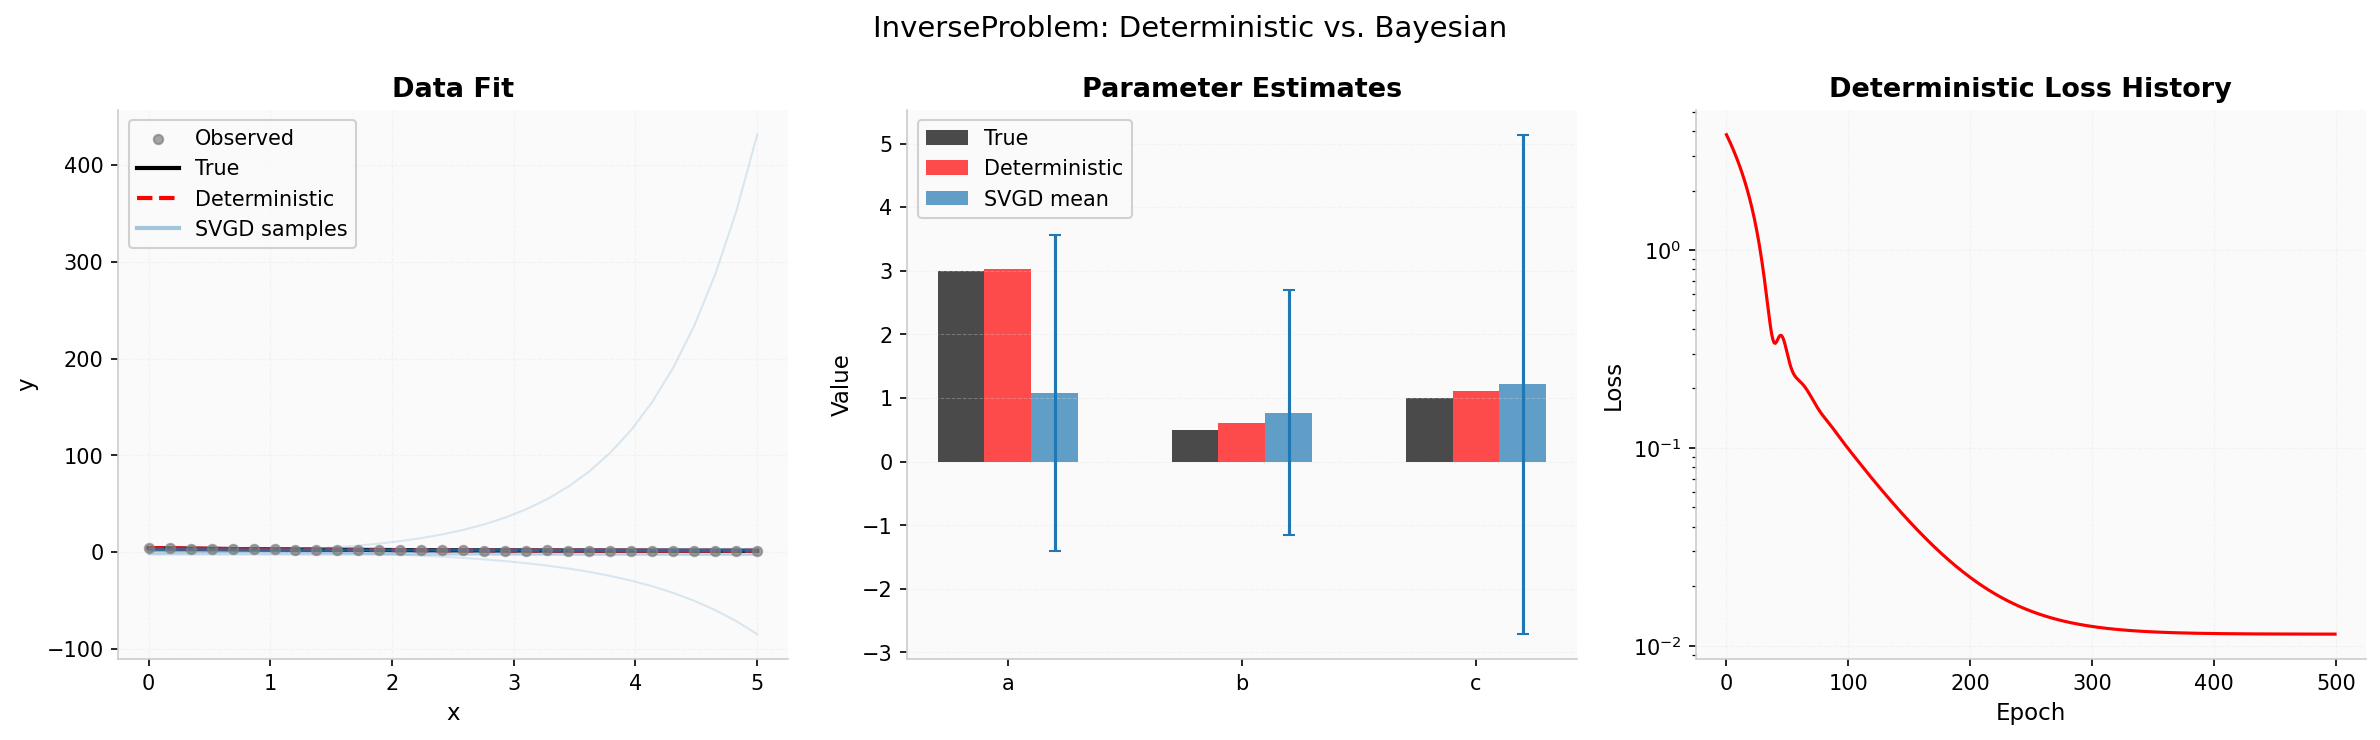


Part 2: Bayesian AVO Inversion


In [1]:
import sys
sys.path.insert(0, '../..')

import os
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from geobrain.optim import bound_constraint
from geobrain.core import InverseProblem
from geobrain.physics.wave import RickerWavelet, Shuey, create_conv_matrix
from geobrain.physics.rock import VRH, Gassmann, SoftSand, DensityModel, v_from_moduli
from geobrain.bayes import Posterior, SVGD, HMC, NUTS, LDS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 2025
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using device: {DEVICE}")


# #############################################################################
# Part 1: InverseProblem Framework Demo (Curve Fitting)
# #############################################################################

print("\n" + "=" * 60)
print("Part 1: InverseProblem Framework Demo")
print("=" * 60)

# True parameters: a=3.0, b=0.5, c=1.0
TRUE_PARAMS = torch.tensor([3.0, 0.5, 1.0])
NOISE_STD_DEMO = 0.1

# Observation locations
x_obs_demo = torch.linspace(0, 5, 30)


def forward_fn_demo(params: torch.Tensor) -> torch.Tensor:
    """Forward model: y = a * exp(-b * x) + c."""
    a, b, c = params[0], params[1], params[2]
    return a * torch.exp(-b * x_obs_demo) + c


# Generate noisy observations
torch.manual_seed(42)
y_true_demo = forward_fn_demo(TRUE_PARAMS)
y_obs_demo = y_true_demo + NOISE_STD_DEMO * torch.randn_like(y_true_demo)

print(f"True parameters: a={TRUE_PARAMS[0]:.2f}, "
      f"b={TRUE_PARAMS[1]:.2f}, c={TRUE_PARAMS[2]:.2f}")
print(f"Observations: {len(x_obs_demo)} points, noise_std={NOISE_STD_DEMO}")

# Create InverseProblem
problem_demo = InverseProblem(
    forward_fn=forward_fn_demo,
    observed=y_obs_demo,
    noise_std=NOISE_STD_DEMO,
)
print(f"\n{problem_demo}")

# --- Deterministic Inversion with Inverter ---
print("\n--- Deterministic Inversion (Inverter) ---")

initial_model = torch.tensor([1.0, 1.0, 0.0])
inverter_demo = problem_demo.create_inverter(
    initial_model=initial_model,
    constraints=bound_constraint(min_val=0.01, max_val=10.0),
)

det_result = inverter_demo.run(
    observed_data=problem_demo.observed,
    max_epochs=500,
    lr=0.02,
    optimizer='adam',
    verbose=True,
    print_every=100,
)

print(f"\n{det_result.summary()}")
det_params = det_result.model.detach()
print(f"Estimated: a={det_params[0]:.3f}, "
      f"b={det_params[1]:.3f}, c={det_params[2]:.3f}")

# --- Bayesian Inference with SVGD ---
print("\n--- Bayesian Inference (SVGD) ---")


def log_prior_demo(theta: torch.Tensor) -> torch.Tensor:
    """Weakly informative Gaussian prior centered at (2, 1, 1)."""
    prior_mean = torch.tensor([2.0, 1.0, 1.0], device=theta.device)
    prior_std = 3.0
    return -0.5 * ((theta - prior_mean) / prior_std).pow(2).sum(dim=-1)


posterior_demo = problem_demo.as_posterior(log_prior=log_prior_demo, dim=3)

svgd_demo = SVGD(target=posterior_demo, lr=0.01)
svgd_demo_result = svgd_demo.run(
    n_samples=50,
    n_steps=500,
    verbose=True,
    print_every=100,
)

samples_demo = svgd_demo_result.samples.detach()
mean_params_demo = samples_demo.mean(dim=0)
std_params_demo = samples_demo.std(dim=0)

print(f"\nPosterior mean:  a={mean_params_demo[0]:.3f}, "
      f"b={mean_params_demo[1]:.3f}, c={mean_params_demo[2]:.3f}")
print(f"Posterior std:   a={std_params_demo[0]:.3f}, "
      f"b={std_params_demo[1]:.3f}, c={std_params_demo[2]:.3f}")

# --- Visualization (Part 1) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.scatter(x_obs_demo.numpy(), y_obs_demo.numpy(), c='gray', s=20, alpha=0.7,
           label='Observed', zorder=3)
ax.plot(x_obs_demo.numpy(), y_true_demo.numpy(), 'k-', lw=2, label='True')
ax.plot(x_obs_demo.numpy(), forward_fn_demo(det_params).detach().numpy(),
        'r--', lw=2, label='Deterministic')
for i in range(min(20, samples_demo.shape[0])):
    y_sample = forward_fn_demo(samples_demo[i]).detach().numpy()
    ax.plot(x_obs_demo.numpy(), y_sample, color='#1f77b4', alpha=0.15, lw=1)
ax.plot([], [], color='#1f77b4', alpha=0.4, lw=2, label='SVGD samples')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data Fit')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
param_names = ['a', 'b', 'c']
x_pos = np.arange(3)
true_vals = TRUE_PARAMS.numpy()
det_vals = det_params.numpy()
mean_vals = mean_params_demo.numpy()
std_vals = std_params_demo.numpy()
ax.bar(x_pos - 0.2, true_vals, 0.2, color='black', alpha=0.7, label='True')
ax.bar(x_pos, det_vals, 0.2, color='red', alpha=0.7, label='Deterministic')
ax.bar(x_pos + 0.2, mean_vals, 0.2, color='#1f77b4', alpha=0.7,
       label='SVGD mean')
ax.errorbar(x_pos + 0.2, mean_vals, yerr=2 * std_vals,
            fmt='none', c='#1f77b4', capsize=3)
ax.set_xticks(x_pos)
ax.set_xticklabels(param_names)
ax.set_ylabel('Value')
ax.set_title('Parameter Estimates')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[2]
loss_hist = det_result.loss_history
ax.semilogy(loss_hist, 'r-', lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Deterministic Loss History')
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('InverseProblem: Deterministic vs. Bayesian', fontsize=14)
fig.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '13_part1_demo.png'))
plt.show()

# Reset seed for Part 2
torch.manual_seed(SEED)
np.random.seed(SEED)


# #############################################################################
# Part 2: Full Bayesian AVO Inversion (All Samplers)
# #############################################################################

print("\n" + "=" * 60)
print("Part 2: Bayesian AVO Inversion")
print("=" * 60)

## Configuration (matches Example 09)

In [2]:
NT = 32  # depth samples

# Physical ranges
PHI_RANGE = (0.05, 0.4)

# Mineral parameters
MINERAL_K = torch.tensor([36.6, 21.0], device=DEVICE)
MINERAL_G = torch.tensor([44.0, 9.0], device=DEVICE)
MINERAL_RHO = torch.tensor([2.65, 2.5], device=DEVICE)
MINERAL_VOL = torch.tensor([0.9, 0.1], device=DEVICE)

# Fluid parameters
FLUID_K = torch.tensor([3.06, 0.10], device=DEVICE)
FLUID_RHO = torch.tensor([1.08, 0.72], device=DEVICE)

# Rock parameters
PRESSURE = 20.0
CRIT_PORO = 0.4
COORD_NUM = 7

# Seismic
ANGLES = [12, 24, 36]
FREQUENCIES = [30, 25, 20]
DT = 0.001

# Noise
NOISE_STD = 0.005

N_ANGLES = len(ANGLES)
N_REFL = NT - 1  # number of reflectivity interfaces
N_DATA = N_ANGLES * N_REFL  # total observations

## Rock-Physics Module

Same VRH → Soft Sand → Gassmann chain, but implemented to support
**batched** input (multiple particles / samples in parallel).

In [3]:
class RockPhysics(nn.Module):
    """Rock physics forward operator: porosity → elastic properties."""

    def __init__(self):
        super().__init__()
        self.vrh = VRH()
        self.granular = SoftSand()
        self.fluid = Gassmann()
        self.density = DensityModel()

    def forward(self, poro, vsand):
        _, _, K_m = self.vrh(MINERAL_VOL, MINERAL_K)
        _, _, G_m = self.vrh(MINERAL_VOL, MINERAL_G)
        rho_m = (MINERAL_RHO * MINERAL_VOL).sum()

        k_fl = FLUID_K[0]
        rho_fl = FLUID_RHO[0]

        press = torch.ones_like(poro) * PRESSURE
        k_dry, g_dry = self.granular(K_m, G_m, poro, CRIT_PORO, COORD_NUM, press)
        k_sat, g_sat = self.fluid(k_dry, g_dry, K_m, k_fl, poro)
        rho = self.density(poro, rho_m, rho_fl)
        vp, vs = v_from_moduli(k_sat, g_sat, rho)
        return vp, vs, rho


rock_physics = RockPhysics().to(DEVICE)

## Generate Wavelets (same as Example 09)

In [4]:
def generate_wavelets(freqs, dt, n_samples):
    """Generate wavelet convolution matrices for each angle stack."""
    ricker = RickerWavelet()
    matrices = []
    for f in freqs:
        w, _ = ricker(f0=float(f), dt=float(dt), device=str(DEVICE))
        W = create_conv_matrix(w, n_samples, mode='same').T
        matrices.append(W)
    return matrices


wavelets = generate_wavelets(FREQUENCIES, DT, N_REFL)
shuey = Shuey()

## Synthetic True Model

A smooth 1-D porosity profile composed of sine and cosine terms.
Seismic observations are generated under 100 % water saturation and
corrupted with Gaussian noise (σ = 0.005).

In [5]:
print("\nGenerating true model...")

# Smooth true porosity profile
z = torch.linspace(0, 1, NT, device=DEVICE)
phi_true = 0.18 + 0.08 * torch.sin(2 * np.pi * z) + 0.04 * torch.cos(4 * np.pi * z)
phi_true = phi_true.clamp(*PHI_RANGE)

# Fixed sand volume (known)
vsand = torch.full((NT,), 0.5, device=DEVICE)

print(f"Porosity: range=[{phi_true.min():.3f}, {phi_true.max():.3f}], shape={phi_true.shape}")

# Compute elastic properties and seismic for the true model
with torch.no_grad():
    vp, vs, rho = rock_physics(phi_true, vsand)

    refl = shuey(vp[:-1], vs[:-1], rho[:-1],
                 vp[1:], vs[1:], rho[1:], theta=ANGLES)
    # refl: [n_angles, N_REFL]

    seis_true = torch.zeros(N_ANGLES, N_REFL, device=DEVICE)
    for i in range(N_ANGLES):
        seis_true[i] = torch.einsum("k,lk->l", refl[i], wavelets[i])

# Add noise
seis_obs = seis_true + NOISE_STD * torch.randn_like(seis_true)
d_obs = seis_obs.flatten()  # [N_DATA]

print(f"Seismic: shape={seis_true.shape}, n_data={N_DATA}")
print(f"Vp range: [{vp.min():.2f}, {vp.max():.2f}] km/s")


Generating true model...
Porosity: range=[0.060, 0.240], shape=torch.Size([32])
Seismic: shape=torch.Size([3, 31]), n_data=93
Vp range: [2382.43, 3239.09] km/s


## Batched Forward Model

`forward_fn(theta)` accepts a `[batch, NT]` porosity matrix and returns
`[batch, N_DATA]` predicted seismic.  This batched design is essential for
efficient SVGD and MCMC sampling.

In [6]:
def forward_fn(theta):
    """
    Batched forward model: porosity profiles → seismic data.

    Args:
        theta: [batch, NT] porosity profiles

    Returns:
        [batch, N_DATA] flattened seismic data
    """
    batch = theta.shape[0]
    poro = theta.clamp(*PHI_RANGE)
    vsand_batch = vsand.unsqueeze(0).expand(batch, -1)

    vp, vs, rho = rock_physics(poro, vsand_batch)

    refl = shuey(vp[:, :-1], vs[:, :-1], rho[:, :-1],
                 vp[:, 1:], vs[:, 1:], rho[:, 1:], theta=ANGLES)
    # refl: [n_angles, batch, N_REFL]

    seis_list = []
    for i in range(N_ANGLES):
        seis_i = torch.einsum("bk,lk->bl", refl[i], wavelets[i])
        seis_list.append(seis_i)

    seis = torch.stack(seis_list, dim=1)  # [batch, n_angles, N_REFL]
    return seis.reshape(batch, -1)

## Posterior Distribution

$$\log p(\theta \mid \mathbf{d}) \propto \underbrace{-\tfrac{1}{2\sigma^2}\|\mathbf{d}_{\text{obs}} - f(\theta)\|^2}_{\text{log-likelihood}} + \underbrace{\log p(\theta)}_{\text{log-prior}}$$

The **prior** combines:

- Marginal Gaussian: $\phi \sim \mathcal{N}(0.2,\, 0.1^2)$ at each depth
- Smoothness penalty: $-\frac{1}{2\sigma_s^2}\sum(\phi_{k+1} - \phi_k)^2$

In [7]:
PRIOR_MEAN = 0.2
PRIOR_STD = 0.1
SMOOTH_STD = 0.01


def log_likelihood(theta, data=None):
    """Gaussian likelihood for seismic data."""
    pred = forward_fn(theta)
    residual = pred - d_obs
    return -0.5 * (residual ** 2).sum(dim=-1) / NOISE_STD ** 2


def log_prior(theta):
    """Gaussian prior with smoothness regularization."""
    # Marginal prior on each porosity value
    marginal = -0.5 * ((theta - PRIOR_MEAN) / PRIOR_STD).pow(2).sum(dim=-1)
    # Smoothness: penalize large differences between adjacent depth samples
    diffs = theta[:, 1:] - theta[:, :-1]
    smooth = -0.5 * (diffs / SMOOTH_STD).pow(2).sum(dim=-1)
    return marginal + smooth


posterior = Posterior(
    log_likelihood=log_likelihood,
    log_prior=log_prior,
    data=d_obs,
    dim=NT,
)

print(f"\n{posterior}")


def init_samples(n):
    """Initialize particles near the prior mean with small perturbation."""
    return PRIOR_MEAN + 0.02 * torch.randn(n, NT, device=DEVICE)


Posterior(dim=32, has_prior=True, has_data=True)


## Method 1 — SVGD (Stein Variational Gradient Descent)

A **deterministic particle** method that transports particles toward the
posterior via gradient information plus a repulsive kernel that maintains
diversity.  50 particles, 500 iterations.

In [8]:
print("\n" + "=" * 60)
print("Method 1: SVGD (Explicit parameterization)")
print("=" * 60)

svgd = SVGD(target=posterior, lr=1e-4, optimizer='adam')
svgd_result = svgd.run(
    n_samples=50,
    n_steps=500,
    initial_samples=init_samples(50),
    verbose=True,
    print_every=100,
)

svgd_phi = svgd_result.samples.detach()
print(f"\n{svgd_result.summary()}")


Method 1: SVGD (Explicit parameterization)

Sampling Result: SVGD
Samples: 50 x 32
Steps: 500
Converged: False
Final log prob: -2.704341e+03
Time: 3.49s


## Method 2 — HMC (Hamiltonian Monte Carlo)

Uses Hamiltonian dynamics (leapfrog integrator) for efficient MCMC
proposals, drastically reducing random-walk behaviour.
10 chains, 300 steps, 100 burn-in, adaptive step size.

In [9]:
print("\n" + "=" * 60)
print("Method 2: HMC (Explicit parameterization)")
print("=" * 60)

hmc = HMC(
    target=posterior,
    step_size=1e-5,
    n_leapfrog=20,
    adapt_step_size=True,
    target_accept_rate=0.65,
)
hmc_result = hmc.run(
    n_samples=10,
    n_steps=300,
    initial_samples=init_samples(10),
    n_burnin=100,
    verbose=True,
    print_every=50,
)

hmc_phi = hmc_result.samples.detach()
print(f"\n{hmc_result.summary()}")


Method 2: HMC (Explicit parameterization)

Sampling Result: HMC
Samples: 10 x 32
Steps: 300
Converged: False
Final log prob: -4.118507e+02
Time: 245.56s


## Method 3 — NUTS (No-U-Turn Sampler)

An adaptive extension of HMC that **automatically** tunes the number of
leapfrog steps.  Max tree depth = 10; other settings match HMC.

In [10]:
print("\n" + "=" * 60)
print("Method 3: NUTS (Explicit parameterization)")
print("=" * 60)

nuts = NUTS(
    target=posterior,
    target_accept_rate=0.65,
    max_tree_depth=10,
)
nuts_result = nuts.run(
    n_samples=10,
    n_steps=300,
    initial_samples=init_samples(10),
    n_burnin=100,
    verbose=True,
    print_every=50,
)

nuts_phi = nuts_result.samples.detach()
print(f"\n{nuts_result.summary()}")


Method 3: NUTS (Explicit parameterization)

Sampling Result: NUTS
Samples: 10 x 32
Steps: 300
Converged: False
Final log prob: -9.957976e+01
Time: 909.41s


## Method 4 — LDS / MALA (Langevin Dynamics Sampler)

Gradient-based MCMC using Langevin diffusion with Metropolis–Hastings
correction.  50 chains, 500 steps, 200 burn-in, adaptive step size.

In [11]:
print("\n" + "=" * 60)
print("Method 4: LDS / MALA (Explicit parameterization)")
print("=" * 60)

lds = LDS(
    target=posterior,
    step_size=1e-5,
    use_mh_correction=True,
    adapt_step_size=True,
    target_accept_rate=0.574,
)
lds_result = lds.run(
    n_samples=50,
    n_steps=500,
    initial_samples=init_samples(50),
    n_burnin=200,
    verbose=True,
    print_every=100,
)

lds_phi = lds_result.samples.detach()
print(f"\n{lds_result.summary()}")


Method 4: LDS / MALA (Explicit parameterization)

Sampling Result: LDS-MALA
Samples: 50 x 32
Steps: 500
Converged: False
Final log prob: -1.344837e+02
Time: 6.47s


## Comparison Across Samplers

| Panel | Content |
|-------|---------|
| **Row 1** | Porosity profiles: posterior mean ± 2σ vs. truth |
| **Row 2, col 1** | Absolute error with RMSE |
| **Row 2, col 2** | Seismic data fit (angle 1) |
| **Row 2, col 3** | Convergence (log-posterior vs. iteration) |
| **Row 2, col 4** | Posterior standard deviation vs. depth |

In [12]:
print("\n" + "=" * 60)
print("Posterior Summary")
print("=" * 60)

COLORS = {
    'SVGD': '#1f77b4',
    'HMC':  '#ff7f0e',
    'NUTS': '#2ca02c',
    'LDS':  '#d62728',
}

all_results = {
    'SVGD': (svgd_phi, svgd_result),
    'HMC':  (hmc_phi, hmc_result),
    'NUTS': (nuts_phi, nuts_result),
    'LDS':  (lds_phi, lds_result),
}

phi_np = phi_true.cpu().numpy()
stats = {}
for name, (phi_samples, _) in all_results.items():
    m = phi_samples.mean(dim=0).cpu()
    s = phi_samples.std(dim=0).cpu()
    rmse = torch.sqrt(((m - phi_true.cpu()) ** 2).mean()).item()
    stats[name] = {'mean': m, 'std': s, 'rmse': rmse}
    print(f"{name:<5} — RMSE: {rmse:.4f}, mean std: {s.mean():.4f}")


Posterior Summary
SVGD  — RMSE: 0.0409, mean std: 0.0195
HMC   — RMSE: 0.0342, mean std: 0.0117
NUTS  — RMSE: 0.0072, mean std: 0.0165
LDS   — RMSE: 0.0115, mean std: 0.0141


## Visualization

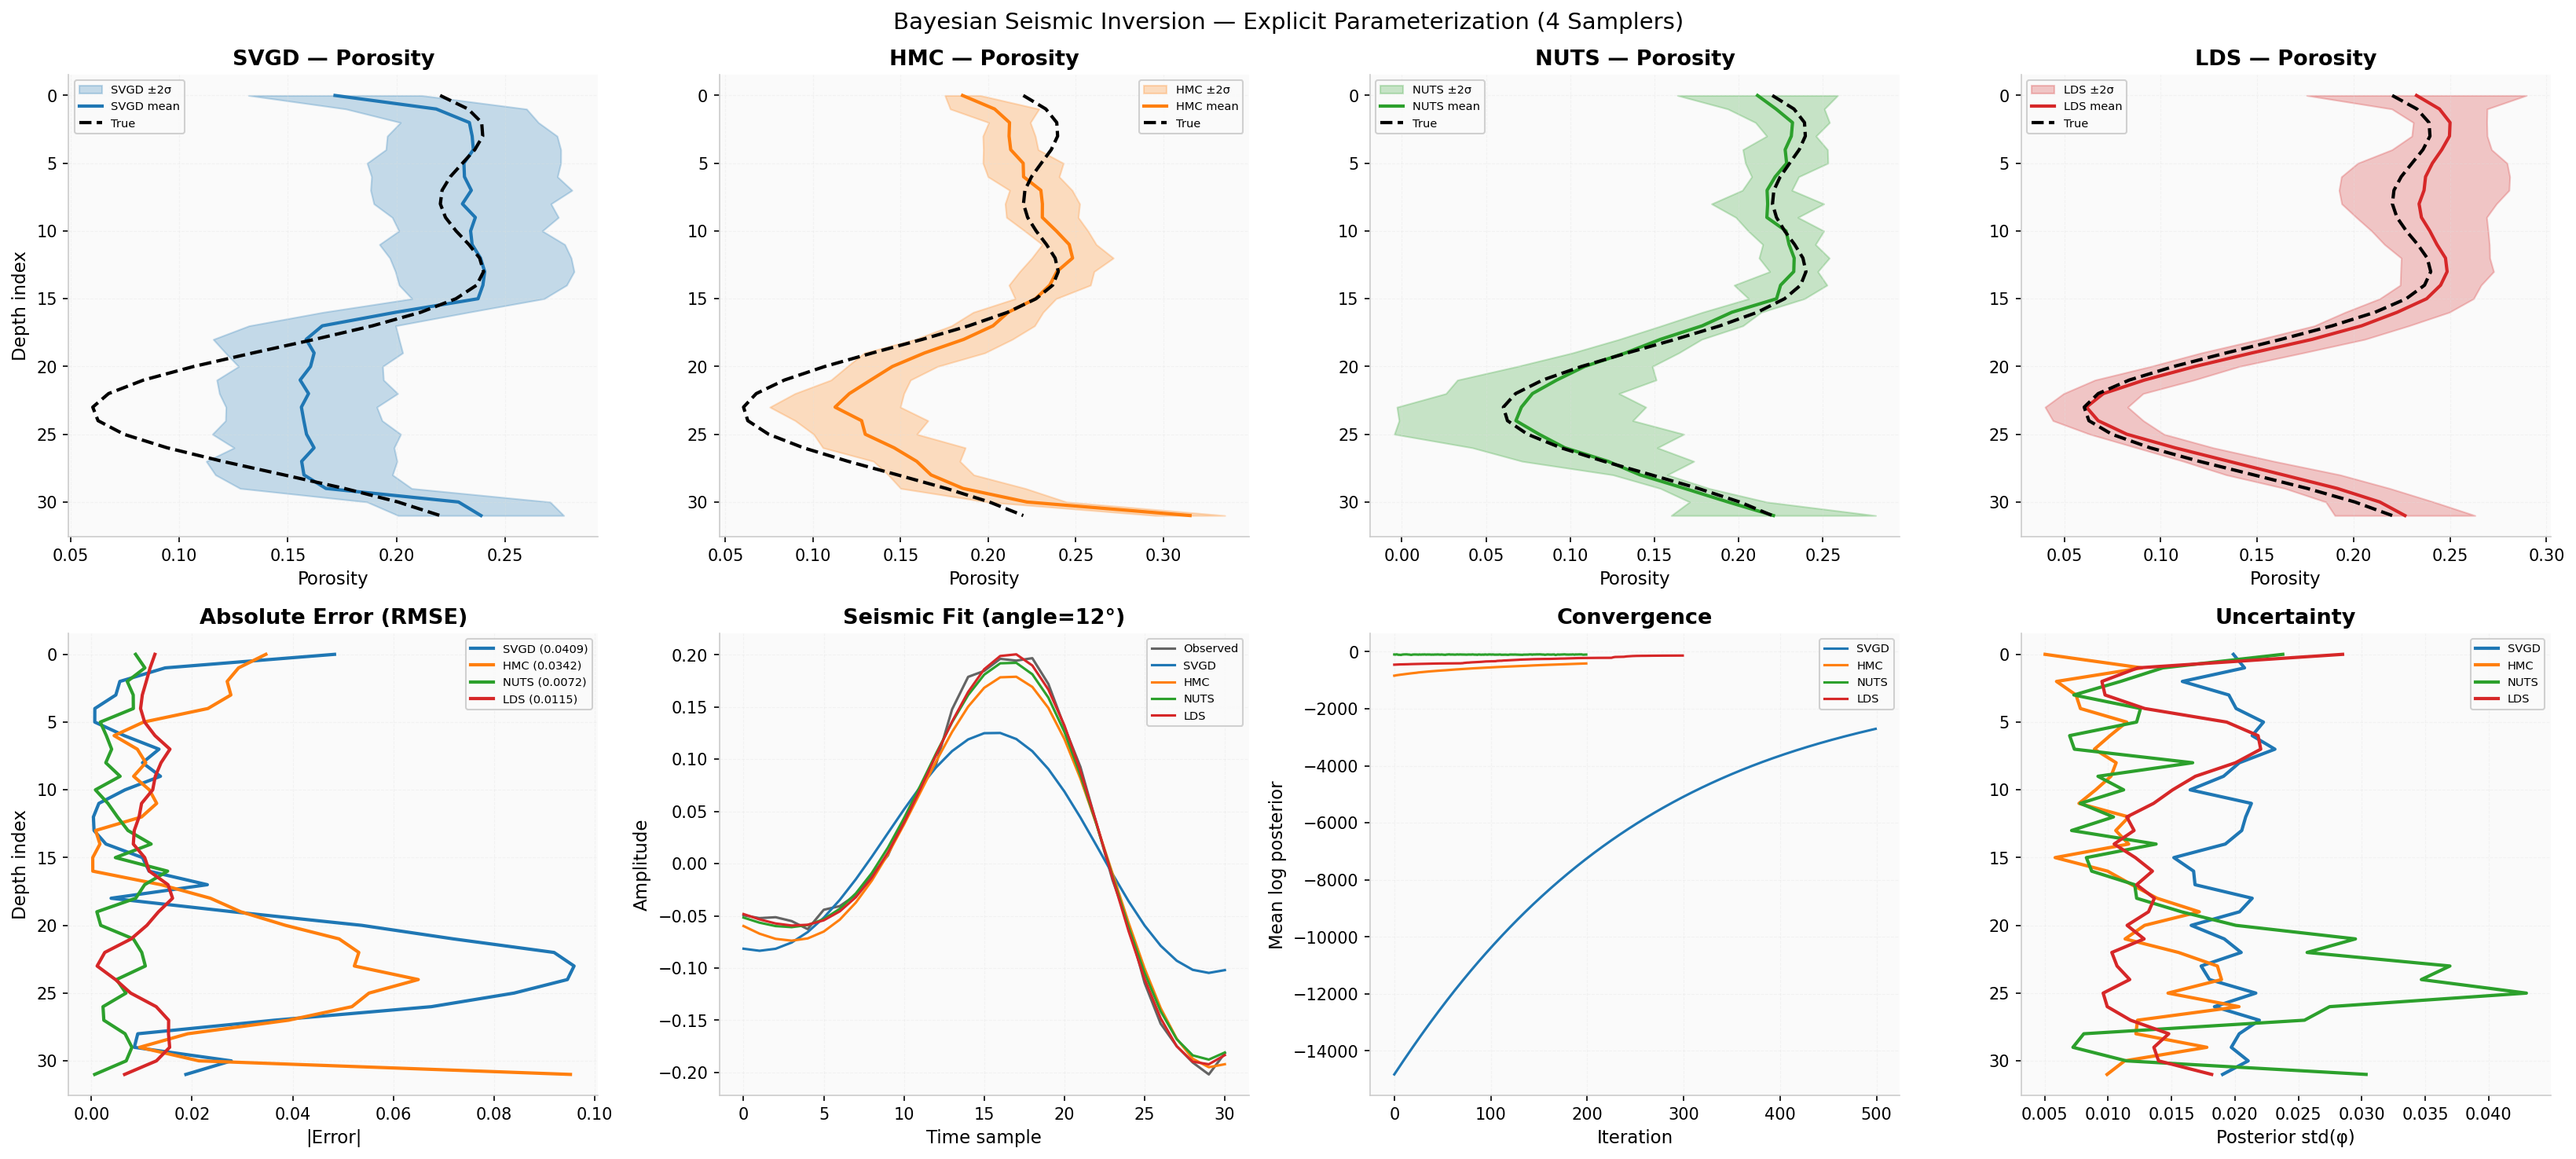


Bayesian AVO inversion complete.


In [13]:
depth = np.arange(NT)
seis_obs_np = seis_obs.cpu().numpy()
time_ax = np.arange(N_REFL)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# --- Row 1: Porosity profiles (one panel per sampler) ---
for col, (name, (phi_samples, _)) in enumerate(all_results.items()):
    ax = axes[0, col]
    m = stats[name]['mean'].numpy()
    s = stats[name]['std'].numpy()
    ax.fill_betweenx(depth, m - 2 * s, m + 2 * s,
                     alpha=0.25, color=COLORS[name], label=f'{name} ±2σ')
    ax.plot(m, depth, '-', color=COLORS[name], lw=2, label=f'{name} mean')
    ax.plot(phi_np, depth, 'k--', lw=2, label='True')
    ax.set_xlabel('Porosity')
    if col == 0:
        ax.set_ylabel('Depth index')
    ax.set_title(f'{name} — Porosity')
    ax.invert_yaxis()
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Row 2, Panel 1: Absolute error (all samplers) ---
ax = axes[1, 0]
for name in all_results:
    rmse = stats[name]['rmse']
    ax.plot(np.abs(stats[name]['mean'].numpy() - phi_np), depth,
            '-', color=COLORS[name], lw=2, label=f'{name} ({rmse:.4f})')
ax.set_xlabel('|Error|')
ax.set_ylabel('Depth index')
ax.set_title('Absolute Error (RMSE)')
ax.invert_yaxis()
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Row 2, Panel 2: Seismic data fit (all samplers, angle 1) ---
ax = axes[1, 1]
angle_idx = 0  # show first angle stack
ax.plot(time_ax, seis_obs_np[angle_idx], 'k-', lw=1.5, alpha=0.6, label='Observed')
for name, (phi_samples, _) in all_results.items():
    with torch.no_grad():
        pred = forward_fn(phi_samples).cpu().numpy()
    pred_mean = pred.mean(axis=0).reshape(N_ANGLES, N_REFL)
    ax.plot(time_ax, pred_mean[angle_idx], '-', color=COLORS[name], lw=1.5,
            label=f'{name}')
ax.set_xlabel('Time sample')
ax.set_ylabel('Amplitude')
ax.set_title(f'Seismic Fit (angle={ANGLES[angle_idx]}°)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Row 2, Panel 3: Convergence ---
ax = axes[1, 2]
for name, (_, result) in all_results.items():
    ax.plot(result.log_prob_history, color=COLORS[name], lw=1.5, label=name)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean log posterior')
ax.set_title('Convergence')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- Row 2, Panel 4: Uncertainty (std) comparison ---
ax = axes[1, 3]
for name in all_results:
    ax.plot(stats[name]['std'].numpy(), depth, '-', color=COLORS[name], lw=2,
            label=name)
ax.set_xlabel('Posterior std(φ)')
ax.set_title('Uncertainty')
ax.invert_yaxis()
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Bayesian Seismic Inversion — Explicit Parameterization (4 Samplers)',
             fontsize=14)
fig.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '13_bayesian_avo_comparison.png'))
plt.show()
print("\nBayesian AVO inversion complete.")